## Load Dataset

In [1]:
import pandas as pd 
# cf_df = pd.read_csv("all_counterfactuals.csv")
# cf_df.head()

In [2]:
df = pd.read_csv("data.csv")

print(df.loc[43424])

past_profitability_21d       0.013125
past_profitability_63d       0.009427
past_profitability_126d      0.049615
volatility_21d               0.057651
volatility_63d               0.064474
volatility_126d              0.071681
avg_price_21d              134.593012
avg_price_63d              133.293962
avg_price_126d             132.296134
sharpe_21d                   0.227948
sharpe_63d                   0.143014
sharpe_126d                  0.691842
m_21d                        1.750662
m_63d                        1.256675
m_126d                       6.394665
roc_21d                      0.013125
roc_63d                      0.009427
roc_126d                     0.049615
MACD                         0.620292
rsi_14                      56.393910
dco_22                      -0.105947
min_21d                    132.906573
min_63d                    130.647882
min_126d                   129.282933
max_21d                    136.198742
max_63d                    136.198742
max_126d    

## Dice

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

import dice_ml
from dice_ml import Dice

# -----------------------
# 1. Load the dataset
# -----------------------


# saved = joblib.load("regressor_with_data.pkl")

# model = saved["model"]

df = pd.read_csv("data.csv")
y = df["target"]

X = df.drop("target", axis=1)



# -----------------------
# 2. Split & sklearn model
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random forest model
model = RandomForestRegressor(n_estimators=20)
model.fit(X_train, y_train)

# -----------------------
# 3. DiCE encapsulation
# -----------------------

d = dice_ml.Data(
    dataframe=df,
    continuous_features=list(X.columns),  # all continuous features
    outcome_name="target"
)



In [4]:
X.columns

Index(['past_profitability_21d', 'past_profitability_63d',
       'past_profitability_126d', 'volatility_21d', 'volatility_63d',
       'volatility_126d', 'avg_price_21d', 'avg_price_63d', 'avg_price_126d',
       'sharpe_21d', 'sharpe_63d', 'sharpe_126d', 'm_21d', 'm_63d', 'm_126d',
       'roc_21d', 'roc_63d', 'roc_126d', 'MACD', 'rsi_14', 'dco_22', 'min_21d',
       'min_63d', 'min_126d', 'max_21d', 'max_63d', 'max_126d', 'exp_mean_21d',
       'exp_mean_63d', 'exp_mean_126d'],
      dtype='object')

In [5]:
y.max()

np.float64(4.398432397126061)

In [12]:
# Sklearn wrapping
m = dice_ml.Model(model=model, backend="sklearn", model_type="regressor")

# -----------------------
# 4. Generate counterfactual with DiCE
# -----------------------
exp = Dice(d, m, method="genetic")  # "random" ou "genetic" ou "kd"

# One instance
query_instance = X_test.iloc[0:1]
print("Factual instance:")
print(query_instance)

# Generate 3 counterfactuals
dice_exp = exp.generate_counterfactuals(query_instance, total_CFs=2, desired_range=[3, 5])

# Visualisation
dice_exp.visualize_as_dataframe(show_only_changes=True)


Factual instance:
       past_profitability_21d  past_profitability_63d  \
43424                0.013125                0.009427   

       past_profitability_126d  volatility_21d  volatility_63d  \
43424                 0.049615        0.057651        0.064474   

       volatility_126d  avg_price_21d  avg_price_63d  avg_price_126d  \
43424         0.071681     134.593012     133.293962      132.296134   

       sharpe_21d  ...    dco_22     min_21d     min_63d    min_126d  \
43424    0.227948  ... -0.105947  132.906573  130.647882  129.282933   

          max_21d     max_63d    max_126d  exp_mean_21d  exp_mean_63d  \
43424  136.198742  136.198742  136.198742     134.67078    133.395036   

       exp_mean_126d  
43424     132.094858  

[1 rows x 30 columns]


100%|██████████| 1/1 [00:00<00:00,  3.80it/s]

Query instance (original outcome : 0.02988690324127674)


,past_profitability_21d,past_profitability_63d,past_profitability_126d,volatility_21d,volatility_63d,volatility_126d,avg_price_21d,avg_price_63d,avg_price_126d,sharpe_21d,...,min_21d,min_63d,min_126d,max_21d,max_63d,max_126d,exp_mean_21d,exp_mean_63d,exp_mean_126d,target
0,0.013125,0.009427,0.049615,0.057651,0.064474,0.071681,134.593018,133.293961,132.296127,0.227948,...,132.90657,130.647888,129.282928,136.198746,136.198746,136.198746,134.670776,133.395035,132.094864,0.029887



Diverse Counterfactual set (new outcome: [3, 5])


,past_profitability_21d,past_profitability_63d,past_profitability_126d,volatility_21d,volatility_63d,volatility_126d,avg_price_21d,avg_price_63d,avg_price_126d,sharpe_21d,...,min_21d,min_63d,min_126d,max_21d,max_63d,max_126d,exp_mean_21d,exp_mean_63d,exp_mean_126d,target
0,-0.0,-0.3,-0.5,0.5,0.6,0.5,7.255,7.716,10.12,-0.1,...,6.727,6.71,6.71,7.596,9.634,14.85,7.25,8.21,10.28,3.2915117081348897
0,-0.0,-0.3,-0.5,0.5,0.6,0.5,7.265,7.763,10.17,-0.1,...,6.732,6.72,6.715,7.596,9.931,14.85,7.29,8.25,10.33,3.2355003463967966


In [7]:
cfs = dice_exp.cf_examples_list[0].final_cfs_df

In [8]:
cfs

,past_profitability_21d,past_profitability_63d,past_profitability_126d,volatility_21d,volatility_63d,volatility_126d,avg_price_21d,avg_price_63d,avg_price_126d,sharpe_21d,...,min_21d,min_63d,min_126d,max_21d,max_63d,max_126d,exp_mean_21d,exp_mean_63d,exp_mean_126d,target
0,0.0,0.0,0.0,0.1,0.1,0.1,134.593,133.294,132.30,0.2,...,132.907,130.65,129.283,136.199,136.199,136.2,134.67,133.40,132.09,0.029887
0,0.0,0.0,0.1,0.1,0.1,0.1,134.510,133.274,132.25,0.2,...,132.885,130.65,128.933,136.199,136.199,136.2,134.61,133.33,132.04,0.031067


In [9]:
query_instance = X_test.iloc[0].values
counterfactual = cfs.iloc[0, :-1].values


In [10]:
counterfactual

array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  1.0000000e-01,
        1.0000000e-01,  1.0000000e-01,  1.3459300e+02,  1.3329400e+02,
        1.3230000e+02,  2.0000000e-01,  1.0000000e-01,  7.0000000e-01,
        1.8000000e+00,  1.3000000e+00,  6.4000000e+00,  0.0000000e+00,
        0.0000000e+00,  0.0000000e+00,  6.0000000e-01,  5.6400000e+01,
       -1.0594704e-01,  1.3290700e+02,  1.3065000e+02,  1.2928300e+02,
        1.3619900e+02,  1.3619900e+02,  1.3620000e+02,  1.3467000e+02,
        1.3340000e+02,  1.3209000e+02])

In [11]:
query_instance.shape

(30,)

## Visualization (incomplete)

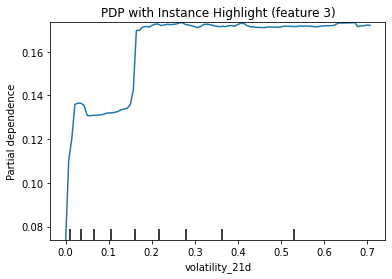

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import plot_partial_dependence





# --- Feature to visualize (index) ---
feature_idx = 3

# Plot PDP
fig, ax = plt.subplots(figsize=(6, 4))
disp = plot_partial_dependence(
    model, X, [feature_idx], ax=ax
)

# Get predictions for instance and counterfactual
orig_pred = model.predict(query_instance.reshape(1, -1))[0]
cf_pred = model.predict(counterfactual.reshape(1, -1))[0]

# Overlay points
ax.scatter(query_instance[feature_idx], orig_pred, color="red", s=80, label="Original")
ax.scatter(counterfactual[feature_idx], cf_pred, color="blue", s=80, label="Counterfactual")

ax.set_title(f"PDP with Instance Highlight (feature {feature_idx})")
ax.legend()
plt.show()


In [41]:
model.predict(counterfactual.reshape(1, -1))

array([0.014434])

In [36]:
query_instance[3]

0.05765056495498325

In [ ]:
all_cf = []

n = len(X_test)

for i in range(n):
    query_instance = X_test.iloc[i:i+1]
    factual_id = query_instance.index[0]

    dice_exp = exp.generate_counterfactuals(
        query_instance,
        total_CFs=2,
        desired_range=[-1, 5]
    )

    cf_df = dice_exp.cf_examples_list[0].final_cfs_df.copy()
    cf_df["factual_id"] = factual_id  # rattache à son factuel

    all_cf.append(cf_df)

# Concaténer tous les contre-factuels
all_cf_df = pd.concat(all_cf, ignore_index=True)



In [ ]:
all_cf_df

,past_profitability_21d,past_profitability_63d,past_profitability_126d,volatility_21d,volatility_63d,...,exp_mean_21d,exp_mean_63d,exp_mean_126d,target,factual_id
0,0.0,0.0,0.0,0.1,0.1,...,134.67,133.40,132.09,0.030630,43424
1,0.0,0.0,0.1,0.1,0.1,...,134.61,133.33,132.04,0.030349,43424
2,0.0,0.0,0.1,0.1,0.1,...,7.19,7.13,7.06,0.076249,6936
3,0.0,0.0,0.0,0.1,0.1,...,7.09,7.04,6.98,0.062459,6936
4,-0.0,-0.0,-0.0,0.0,0.0,...,15.80,15.82,15.85,0.002447,31466
5,-0.0,-0.0,-0.0,0.0,0.0,...,15.79,15.82,15.85,0.003612,31466
6,0.1,0.1,-0.1,0.4,0.4,...,0.11,0.11,0.12,1.131674,25983
7,0.1,0.1,-0.2,0.5,0.5,...,0.14,0.13,0.14,0.325742,25983
8,0.0,0.0,0.0,0.0,0.0,...,129.76,129.61,129.58,0.004617,33206
9,0.0,0.0,0.0,0.0,0.0,...,129.75,129.60,129.58,0.005011,33206


In [ ]:
# Sauvegarder en CSV
all_cf_df.to_csv("all_counterfactuals.csv", index=False)

print("Saved counterfactuals shape:", all_cf_df.shape)

In [37]:
from termcolor import colored

def highlight_changes(factual, counterfactual):
    """Affiche chaque feature, en rouge si modifiée"""
    for col in factual.index:
        f_val = factual[col]
        c_val = counterfactual[col]
        if f_val != c_val:
            print(col, ":", colored(f_val, "green"), "→", colored(c_val, "red"))
        else:
            print(col, ":", f_val)
    print("-" * 40)


In [39]:
# Exemple : visualiser pour le premier factuel
factual_id = all_cf_df["factual_id"].iloc[0]
factual = X_test.loc[factual_id]

subset = all_cf_df[all_cf_df["factual_id"] == factual_id]

for idx, row in subset.iterrows():
    print(f"\nCounterfactual {idx}:")
    highlight_changes(factual, row.drop("factual_id"))


Counterfactual 0:
past_profitability_21d : 0.013124796161433385 → 0.0
past_profitability_63d : 0.009426592311404544 → 0.0
past_profitability_126d : 0.04961471455384001 → 0.0
volatility_21d : 0.05765056495498325 → 0.1
volatility_63d : 0.06447394071104759 → 0.1
volatility_126d : 0.07168149338292021 → 0.1
avg_price_21d : 134.59301220857148 → 134.593
avg_price_63d : 133.29396167015872 → 133.294
avg_price_126d : 132.29613423555548 → 132.3
sharpe_21d : 0.2279481599864203 → 0.2
sharpe_63d : 0.1430142452491993 → 0.1
sharpe_126d : 0.6918415787276683 → 0.7
m_21d : 1.7506622000000047 → 1.8
m_63d : 1.2566752199999995 → 1.3
m_126d : 6.394665260000003 → 6.4
roc_21d : 0.013124796161433385 → 0.0
roc_63d : 0.009426592311404544 → 0.0
roc_126d : 0.04961471455384001 → 0.0
MACD : 0.6202922425811721 → 0.6
rsi_14 : 56.39391047485839 → 56.4
dco_22 : -0.10594704272720604 → -0.10594704
min_21d : 132.90657347999988 → 132.907
min_63d : 130.6478815000001 → 130.65
min_126d : 129.28293328000007 → 129.283
max_21d : 

In [ ]:
# Sauvegarder en CSV
all_cf_df.to_csv("all_counterfactuals.csv", index=False)

print("Saved counterfactuals shape:", all_cf_df.shape)

## CARLA

In [22]:
from carla.data.catalog import CsvCatalog

#continuous = ["age", "fnlwgt", "education-num", "capital-gain", "hours-per-week", "capital-loss"]
#categorical = ["marital-status", "native-country", "occupation", "race", "relationship", "sex", "workclass"]
#immutable = ["age", "sex"]
file_path = "training_data.csv" # Path to your data

dataset = CsvCatalog(file_path=file_path,
                     continuous=continuous,
                     categorical=[],
                     immutables=[],
                     target='target')

display(dataset.df.head())

,past_profitability_21d,past_profitability_63d,past_profitability_126d,volatility_21d,volatility_63d,...,max_126d,exp_mean_21d,exp_mean_63d,exp_mean_126d,target
0,0.136332,0.169568,0.211132,0.008955,0.017334,...,0.0011,0.000881,0.000898,0.000927,0.048596
1,0.135998,0.173294,0.212602,0.009270,0.017363,...,0.0011,0.000884,0.000898,0.000927,0.055726
2,0.133644,0.172705,0.210647,0.009641,0.017483,...,0.0011,0.000885,0.000898,0.000926,0.068956
3,0.130236,0.171356,0.204992,0.010008,0.017608,...,0.0011,0.000885,0.000898,0.000925,0.087021
4,0.127791,0.168613,0.199268,0.010343,0.017683,...,0.0011,0.000884,0.000897,0.000924,0.116883


In [3]:
# load catalog model
model_type = "forest"
ml_model = MLModelCatalog(
    dataset,
    model_type=model_type,
    load_online=True,
    backend="sklearn"
)

In [4]:


# define your recourse method
recourse_method = recourse_catalog.Dice(ml_model, hyperparams={})


In [5]:
# get some negative instances
factuals = predict_negative_instances(ml_model, dataset.df)
factuals = factuals[:5]

# find counterfactuals
counterfactuals = recourse_method.get_counterfactuals(factuals)

In [6]:
counterfactuals

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,0.301370,0.044131,0.800000,0.02174,0.0,0.459799
1,0.452055,0.048052,0.800000,0.00000,0.0,0.946284
2,0.287671,0.137581,0.858199,0.00000,0.0,0.936285
3,0.493151,0.150486,0.952120,0.00000,0.0,0.823724
4,0.150685,0.220635,0.800000,0.70000,0.0,0.397959


In [7]:
factuals

,age,fnlwgt,education-num,capital-gain,capital-loss,...,occupation_Other,race_White,relationship_Non-Husband,sex_Male,workclass_Private
0,0.301370,0.044131,0.800000,0.02174,0.0,...,0.0,1.0,1.0,1.0,0.0
1,0.452055,0.048052,0.800000,0.00000,0.0,...,0.0,1.0,0.0,1.0,0.0
2,0.287671,0.137581,0.533333,0.00000,0.0,...,1.0,1.0,1.0,1.0,1.0
3,0.493151,0.150486,0.400000,0.00000,0.0,...,1.0,0.0,0.0,1.0,1.0
4,0.150685,0.220635,0.800000,0.00000,0.0,...,0.0,0.0,1.0,0.0,1.0
